<a href="https://colab.research.google.com/github/buddercakes/Bioengineering-QRG/blob/main/LN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step    0: mean outlet ux = 0.0000
Step   50: mean outlet ux = 0.0000
Step  100: mean outlet ux = 0.0025
Step  150: mean outlet ux = 0.0110
Step  200: mean outlet ux = 0.0110
Step  250: mean outlet ux = 0.0106
Step  300: mean outlet ux = 0.0101
Step  350: mean outlet ux = 0.0094
Step  400: mean outlet ux = 0.0089
Step  450: mean outlet ux = 0.0085
Step  500: mean outlet ux = 0.0082
Step  550: mean outlet ux = 0.0079
Step  600: mean outlet ux = 0.0076
Step  650: mean outlet ux = 0.0073
Step  700: mean outlet ux = 0.0070
Step  750: mean outlet ux = 0.0067
Step  800: mean outlet ux = 0.0065
Step  850: mean outlet ux = 0.0062
Step  900: mean outlet ux = 0.0060
Step  950: mean outlet ux = 0.0058
Step 1000: mean outlet ux = 0.0055
Step 1050: mean outlet ux = 0.0053
Step 1100: mean outlet ux = 0.0051
Step 1150: mean outlet ux = 0.0049
Step 1200: mean outlet ux = 0.0047
Step 1250: mean outlet ux = 0.0045
Step 1300: mean outlet ux = 0.0044
Step 1350: mean outlet ux = 0.0042
Step 1400: mean outl

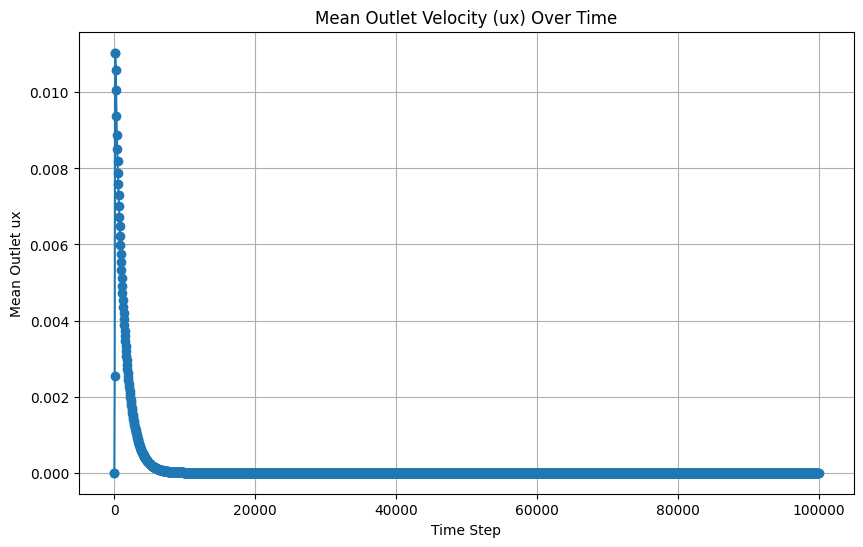

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# D3Q19 LBM with multi-inlet pulsatile flow (BGK)
# -----------------------------

# D3Q19 discrete velocities and weights
c = np.array([
    [ 0,  0,  0],
    [ 1,  0,  0], [-1,  0,  0],
    [ 0,  1,  0], [ 0, -1,  0],
    [ 0,  0,  1], [ 0,  0, -1],
    [ 1,  1,  0], [-1, -1,  0],
    [ 1, -1,  0], [-1,  1,  0],
    [ 1,  0,  1], [-1,  0, -1],
    [ 1,  0, -1], [-1,  0,  1],
    [ 0,  1,  1], [ 0, -1, -1],
    [ 0,  1, -1], [ 0, -1,  1],
], dtype=np.int64)

w = np.array([
    1/3,
    1/18, 1/18, 1/18, 1/18, 1/18, 1/18,
    1/36, 1/36, 1/36, 1/36, 1/36, 1/36,
    1/36, 1/36, 1/36, 1/36, 1/36, 1/36
], dtype=np.float64)

cs2 = 1.0/3.0  # speed of sound^2 in lattice units

# -----------------------------
# Domain + physical-ish mapping (example values)
# -----------------------------

Nx, Ny, Nz = 60, 24, 24   # x = flow direction, y,z = cross-section

rho0       = 1.0
U_mean_lb  = 0.05         # target mean outlet velocity (lattice units)
alpha      = 0.25         # ±25% pulsation of each inlet
f_phys     = 0.5          # Hz (example pulsation frequency)
dt_phys    = 2.5e-3       # s (example mapping)
omega_lb   = 2.0 * np.pi * f_phys * dt_phys  # lattice angular frequency

# Relaxation time for momentum (viscosity via tau)
tau_flow  = 0.8
omega_col = 1.0 / tau_flow

# -----------------------------
# Inlet configuration: 4 inlets (2x2) on x=0 plane
# -----------------------------

N_inlets_y = 2
N_inlets_z = 2
N_inlets   = N_inlets_y * N_inlets_z

patch_height = Ny // N_inlets_y
patch_width  = Nz // N_inlets_z

inlet_centers = []
inlet_extents = []  # (hy, hz) in nodes

for iy in range(N_inlets_y):
    for iz in range(N_inlets_z):
        y0 = iy * patch_height
        y1 = (iy + 1) * patch_height - 1
        z0 = iz * patch_width
        z1 = (iz + 1) * patch_width - 1
        y_mid = 0.5 * (y0 + y1)
        z_mid = 0.5 * (z0 + z1)
        hy = 0.5 * (y1 - y0 + 1)
        hz = 0.5 * (z1 - z0 + 1)
        inlet_centers.append((y_mid, z_mid))
        inlet_extents.append((hy, hz))


def inlet_center_velocity(i_inlet: int, n_step: int) -> float:
    """Time-dependent centerline velocity for inlet i at time step n (lattice units)."""
    phi_i = 2.0 * np.pi * i_inlet / N_inlets  # evenly spaced phases
    return U_mean_lb * (1.0 + alpha * np.sin(omega_lb * n_step + phi_i))


def inlet_velocity_profile(i_inlet: int, y: int, z: int, n_step: int) -> float:
    """Parabolic (in y,z) profile inside each inlet patch on x=0."""
    Uc = inlet_center_velocity(i_inlet, n_step)
    (y_mid, z_mid) = inlet_centers[i_inlet]
    (hy, hz) = inlet_extents[i_inlet]

    # normalized coordinates in [-1,1]
    eta_y = (y - y_mid) / hy
    eta_z = (z - z_mid) / hz

    profile = (1.0 - eta_y**2) * (1.0 - eta_z**2)
    if profile < 0.0:
        profile = 0.0
    return Uc * profile


# -----------------------------
# Utility: equilibrium
# -----------------------------

def equilibrium(rho, ux, uy, uz):
    """Compute D3Q19 equilibrium distributions for given rho, u fields."""
    u_sq = ux**2 + uy**2 + uz**2
    feq = np.empty((19,) + rho.shape, dtype=np.float64)
    for q in range(19):
        cu = c[q,0]*ux + c[q,1]*uy + c[q,2]*uz
        feq[q] = w[q] * rho * (1.0 + 3.0*cu + 4.5*cu**2 - 1.5*u_sq)
    return feq


# -----------------------------
# Initialization
# -----------------------------

rho = rho0 * np.ones((Nx, Ny, Nz), dtype=np.float64)
ux  = np.zeros_like(rho)
uy  = np.zeros_like(rho)
uz  = np.zeros_like(rho)

# Distribution function f[q, x, y, z]
f = equilibrium(rho, ux, uy, uz)

# Solid mask for walls / matrix: False=fluid, True=solid
solid = np.zeros((Nx, Ny, Nz), dtype=bool)

# Solid walls on y,z boundaries
solid[:, 0, :]      = True
solid[:, Ny-1, :]   = True
solid[:, :, 0]      = True
solid[:, :, Nz-1]   = True

# Example porous block (lymph-node matrix) in middle (uncomment to use)
# solid[20:40, 6:18, 6:18] = True

# D3Q19 opposite directions for bounce-back
opp = np.array([0, 2, 1, 4, 3, 6, 5,
                8, 7,10, 9,12,11,14,13,16,15,18,17], dtype=int)

# -----------------------------
# Main LBM loop (skeleton)
# -----------------------------

Nt = 100000  # time steps; increase for real runs

mean_u_out_history = []
time_steps_history = []

for n in range(Nt):

    # --- Macros + collision ---
    rho = np.sum(f, axis=0)
    ux  = np.sum(f * c[:,0].reshape(19,1,1,1), axis=0) / rho
    uy  = np.sum(f * c[:,1].reshape(19,1,1,1), axis=0) / rho
    uz  = np.sum(f * c[:,2].reshape(19,1,1,1), axis=0) / rho

    # no-slip in solids
    ux[solid] = 0.0
    uy[solid] = 0.0
    uz[solid] = 0.0

    feq = equilibrium(rho, ux, uy, uz)
    f = (1.0 - omega_col) * f + omega_col * feq

    # --- Streaming ---
    f_streamed = np.empty_like(f)
    for q in range(19):
        cx, cy, cz = c[q]
        f_streamed[q] = np.roll(
            np.roll(
                np.roll(f[q], cx, axis=0),
                cy, axis=1),
            cz, axis=2
        )
    f = f_streamed

    # --- Bounce-back on solids ---
    for q in range(19):
        bounced = f[q].copy()
        f[q][solid]       = f[opp[q]][solid]
        f[opp[q]][solid]  = bounced[solid]

    # --- Inlet BC: pulsatile velocity on x = 0 patches ---
    x_in = 0
    inlet_id = 0
    for iy in range(N_inlets_y):
        for iz in range(N_inlets_z):
            y0 = iy * patch_height
            y1 = (iy + 1) * patch_height
            z0 = iz * patch_width
            z1 = (iz + 1) * patch_width

            for y in range(y0, y1):
                for z in range(z0, z1):
                    if solid[x_in, y, z]:
                        continue

                    ux_bc = inlet_velocity_profile(inlet_id, y, z, n)
                    uy_bc = 0.0
                    uz_bc = 0.0
                    rho_bc = rho0

                    feq_bc = equilibrium(
                        rho_bc * np.ones((1,1,1)),
                        ux_bc * np.ones((1,1,1)),
                        uy_bc * np.ones((1,1,1)),
                        uz_bc * np.ones((1,1,1)),
                    )[:,0,0,0]

                    for q in range(19):
                        f[q, x_in, y, z] = feq_bc[q]

            inlet_id += 1

    # --- Outlet BC: zero-gradient at x = Nx-1 ---
    x_out = Nx - 1
    f[:, x_out, :, :] = f[:, x_out-1, :, :]

    # --- Quick diagnostic ---
    if n % 50 == 0:
        rho = np.sum(f, axis=0)
        ux  = np.sum(f * c[:,0].reshape(19,1,1,1), axis=0) / rho
        mean_u_out = np.mean(ux[x_out,:,:])
        print(f"Step {n:4d}: mean outlet ux = {mean_u_out:.4f}")
        mean_u_out_history.append(mean_u_out)
        time_steps_history.append(n)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_steps_history, mean_u_out_history, marker='o', linestyle='-')
plt.title('Mean Outlet Velocity (ux) Over Time')
plt.xlabel('Time Step')
plt.ylabel('Mean Outlet ux')
plt.grid(True)
plt.show()